<a href="https://colab.research.google.com/github/arshiyapandey/AI-Mental-Health-Risk-Analyzer/blob/main/mental_health_risk_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Title: AI Mental Health Risk Analyzer

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/ai-mental-health-project/data/raw/Mental Health Dataset.csv.zip"

df = pd.read_csv(file_path)

df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


#### EDA Processes

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [ ]:
df.describe()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


In [ ]:
# Checking for null values
print(df.isnull().sum())

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64


In [ ]:
df = df.drop("Timestamp", axis=1)

In [ ]:
print(df["self_employed"].value_counts())

self_employed
No     257994
Yes     29168
Name: count, dtype: int64


In [ ]:
# Filling missing values (NaN) with unknown
df["self_employed"] = df["self_employed"].fillna("Unknown")

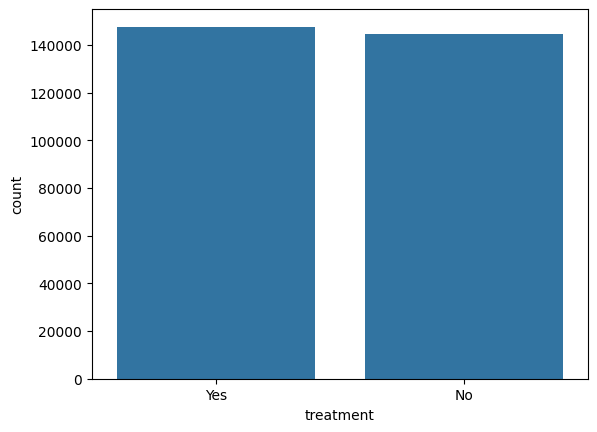

In [ ]:
sns.countplot(x="treatment", data=df)
plt.show()

In [ ]:
pd.crosstab(df["Growing_Stress"], df["treatment"])

treatment,No,Yes
Growing_Stress,,
Maybe,50020,49965
No,46097,46629
Yes,48641,51012


In [ ]:
pd.crosstab(df["Mood_Swings"], df["treatment"])

treatment,No,Yes
Mood_Swings,,
High,45002,46464
Low,49548,50286
Medium,50208,50856


In [ ]:
pd.crosstab(df["Coping_Struggles"], df["treatment"])

treatment,No,Yes
Coping_Struggles,,
No,77141,77187
Yes,67617,70419


In [ ]:
pd.crosstab(df["Social_Weakness"], df["treatment"])

treatment,No,Yes
Social_Weakness,,
Maybe,51346,52047
No,48083,49281
Yes,45329,46278


In [ ]:
pd.crosstab(df["Days_Indoors"], df["treatment"])

treatment,No,Yes
Days_Indoors,,
1-14 days,31781,31767
15-30 days,26538,27291
31-60 days,30060,30645
Go out Every day,28777,29589
More than 2 months,27602,28314


In [ ]:
df.dtypes

,0
Gender,object
Country,object
Occupation,object
self_employed,object
family_history,object
treatment,object
Days_Indoors,object
Growing_Stress,object
Changes_Habits,object
Mental_Health_History,object


In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['Gender', 'Country', 'Occupation', 'self_employed', 'family_history',
       'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
       'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
       'Work_Interest', 'Social_Weakness', 'mental_health_interview',
       'care_options'],
      dtype='object')


In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in categorical_columns:
    df[column] = le.fit_transform(df[column])

In [ ]:
df.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,34,1,1,0,1,0,2,1,2,2,0,1,2,1,1
1,0,34,1,1,1,1,0,2,1,2,2,0,1,2,1,0
2,0,34,1,1,1,1,0,2,1,2,2,0,1,2,1,2
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2


In [ ]:
# Target 'treatment'
y = df['treatment']
X = df.drop('treatment', axis=1)

In [ ]:
# Train-test split (20% Testing Data)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
test_size = 0.2,
random_state = 42 )

#### Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter= 1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_log = log_model.predict(X_test)

In [ ]:
# Probability prediction
y_prob_log = log_model.predict_proba(X_test)

In [ ]:
# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1_score = f1_score(y_test, y_pred_log)

print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred_log)
print(cm)

print("----------------------------------")
print("Accuracy Score:", accuracy)
print("Precision Score:", precision)
print("Recall Score:", recall)
print("F1 Score:", f1_score)
print("----------------------------------")

print("Classification Report:")
print(classification_report(y_test, y_pred_log))


Confusion Matrix
[[19863  9032]
 [ 8321 21257]]
----------------------------------
Accuracy Score: 0.7032305508525303
Precision Score: 0.7018059361484367
Recall Score: 0.7186760430049361
F1 Score: 0.7101408121335627
----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.69      0.70     28895
           1       0.70      0.72      0.71     29578

    accuracy                           0.70     58473
   macro avg       0.70      0.70      0.70     58473
weighted avg       0.70      0.70      0.70     58473



### Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth = 10, min_samples_split=20,random_state= 42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [ ]:
# Model evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("-------------------------------------------")

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.781403382757854
-------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.72      0.77     28895
           1       0.75      0.84      0.80     29578

    accuracy                           0.78     58473
   macro avg       0.79      0.78      0.78     58473
weighted avg       0.78      0.78      0.78     58473



### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Model Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("-------------------------------------------")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.766268192157064
-------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.73      0.76     28895
           1       0.75      0.80      0.78     29578

    accuracy                           0.77     58473
   macro avg       0.77      0.77      0.77     58473
weighted avg       0.77      0.77      0.77     58473



### MODEL COMPARISON


In [ ]:
model_results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
}

results_df = pd.DataFrame(model_results)
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.703231
1        Decision Tree  0.781403
2        Random Forest  0.766268


### Feature Importance

In [ ]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10)

,0
family_history,0.356951
care_options,0.258561
Country,0.178007
Gender,0.069178
mental_health_interview,0.061230
self_employed,0.050899
Occupation,0.004021
Days_Indoors,0.003929
Mood_Swings,0.002684
Social_Weakness,0.002637


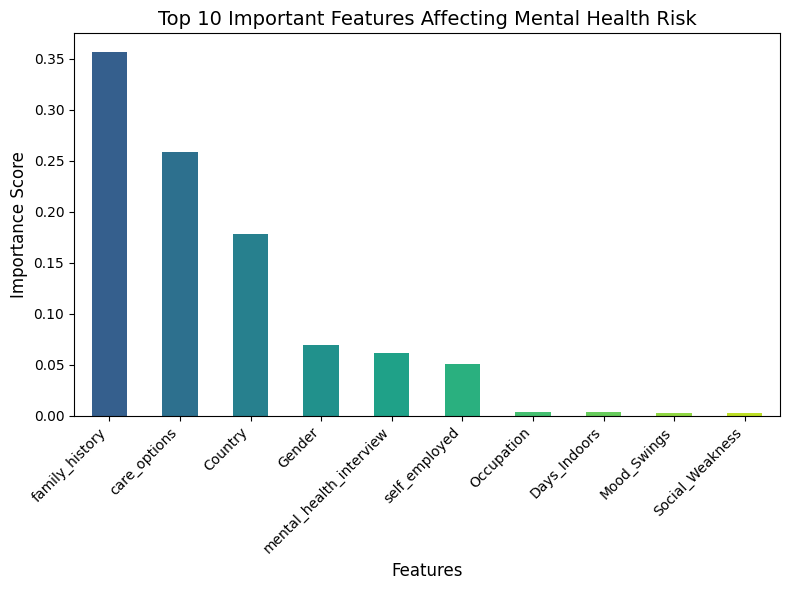

In [ ]:
top_features = feature_importance.sort_values(ascending=False).head(10)

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
plt.figure(figsize=(8, 6))
top_features.plot(kind='bar', color=colors)



plt.title("Top 10 Important Features Affecting Mental Health Risk", fontsize =14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance Score", fontsize =12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Interpretation:
####
The analysis found that a Family History of mental health struggles is the most important predictor of risk. The availability of Care Options also plays a significant role suggesting that access to mental health care resources may influence mental health outcomes.

Additionally, demographic factors such as Country and Gender contribute to the model's predictions which may reflect differences in social environment, cultural attitudes toward mental health and access to healthcare systems.

Other variables such as mental_health_interview and self_employed have moderate importance, indicating that workplace factors and employment conditions may also affect mental health risk.
